# GC bias

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [147]:
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Single cell


In [148]:
data = []
basedir = Path("../analysis/downsample_40M/downstream/picard")
assert basedir.exists()
for file in basedir.rglob("*.gc_bias_metrics.txt"):
    sample = file.stem.split(".")[0]
    d = pd.read_csv(file, sep="\t", skiprows=6)
    d["NGI ID"] = sample

    data.append(d)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="NGI ID")
data.head()

,ACCUMULATION_LEVEL,READS_USED,GC,WINDOWS,READ_STARTS,MEAN_BASE_QUALITY,NORMALIZED_COVERAGE,ERROR_BAR_WIDTH,SAMPLE,LIBRARY,READ_GROUP,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Type
0,All Reads,ALL,0,133402,520,17,0.140437,0.006159,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell
1,All Reads,ALL,1,96778,179,16,0.066637,0.004981,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell
2,All Reads,ALL,2,112145,270,17,0.086741,0.005279,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell
3,All Reads,ALL,3,142995,459,18,0.115646,0.005398,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell
4,All Reads,ALL,4,154320,581,18,0.135642,0.005627,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell


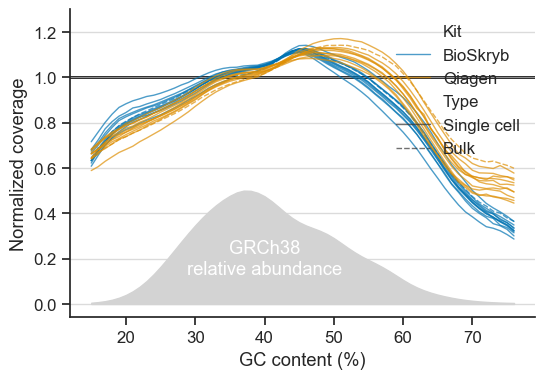

In [165]:
d = data.query("WINDOWS > 1000_000")
fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.lineplot(
    data=d, 
    x="GC", 
    y="NORMALIZED_COVERAGE", 
    hue="Kit",
    hue_order=sorted(data["Kit"].unique()),
    style="Type",
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.7,
    ax=ax,
    )

# Add heatmap with relative bin abundance in GRCh38
_ = ax.annotate("GRCh38\nrelative abundance", xy=(40, 0.2), ha="center", va="center", color="white")
for _, d in d.groupby(["User ID"]):
    break
y = (d["WINDOWS"] / d["WINDOWS"].max()).values  / 2 
x = d["GC"]
ax.fill_between(x, y, color="lightgrey")

plt.legend(frameon=False, framealpha=0, loc="upper right")
sns.move_legend(ax, loc="upper right")
ax.set_ylim(top=1.3)
ax.set_ylabel("Normalized coverage")
ax.set_xlabel("GC content (%)")

ax.grid(axis="y",  alpha=0.7)
ax.axhline(1, ls="-", color="black", lw=2, zorder=-1)

plt.savefig(figdir / "gc_bias.svg", bbox_inches="tight")